# Predicción de Tsunamis

## ¿Qué modelo elegir?

In [10]:
# PASO 1: Cargar los datos y ver cómo son
import pandas as pd  # Para manejar tablas de datos
import matplotlib.pyplot as plt  # Para hacer gráficos
import seaborn as sns  # Para hacer gráficos bonitos
import numpy as np  # Para hacer cálculos numéricos

# Leemos el archivo CSV con los datos de terremotos y tsunamis
df = pd.read_csv('earthquake_data_tsunami.csv')

# Mostramos las primeras filas para ver cómo son los datos
print(df.head())  # Así vemos qué columnas hay y cómo son los valores

   magnitude  cdi  mmi  sig  nst   dmin   gap    depth  latitude  longitude  \
0        7.0    8    7  768  117  0.509  17.0   14.000   -9.7963    159.596   
1        6.9    4    4  735   99  2.229  34.0   25.000   -4.9559    100.738   
2        7.0    3    3  755  147  3.125  18.0  579.000  -20.0508   -178.346   
3        7.3    5    5  833  149  1.865  21.0   37.000  -19.2918   -172.129   
4        6.6    0    2  670  131  4.998  27.0  624.464  -25.5948    178.278   

   Year  Month  tsunami  
0  2022     11        1  
1  2022     11        0  
2  2022     11        1  
3  2022     11        1  
4  2022     11        1  


### ¿Está el dataset equilibrado?

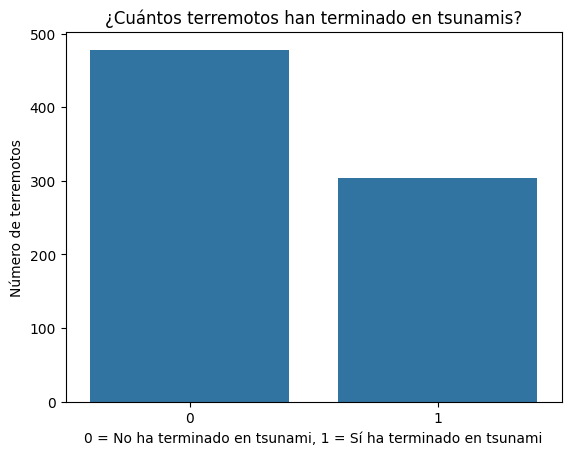

In [11]:
# PASO 2: Ver cuántos terremotos han terminado en tsunamis y cuántos no
# Esto nos ayuda a saber si los datos están equilibrados (o sea, si hay más terremotos que no terminan en tsunami)
sns.countplot(x='tsunami', data=df)
plt.title('¿Cuántos terremotos han terminado en tsunamis?')
plt.xlabel('0 = No ha terminado en tsunami, 1 = Sí ha terminado en tsunami')
plt.ylabel('Número de terremotos')
plt.show()

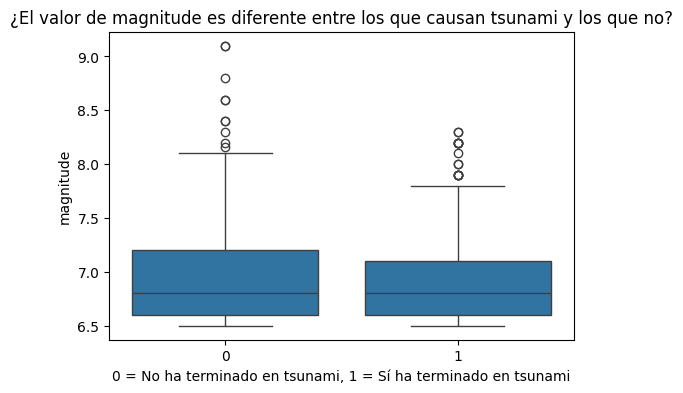

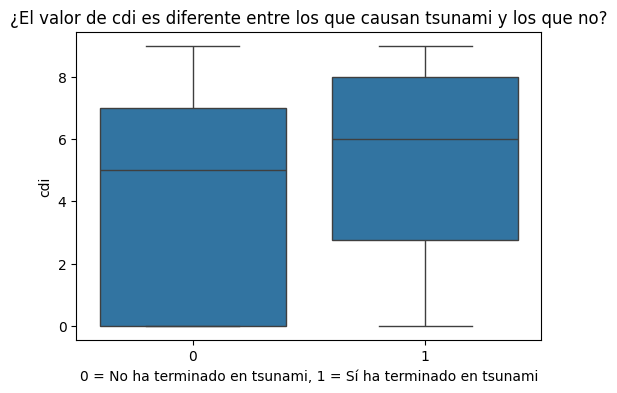

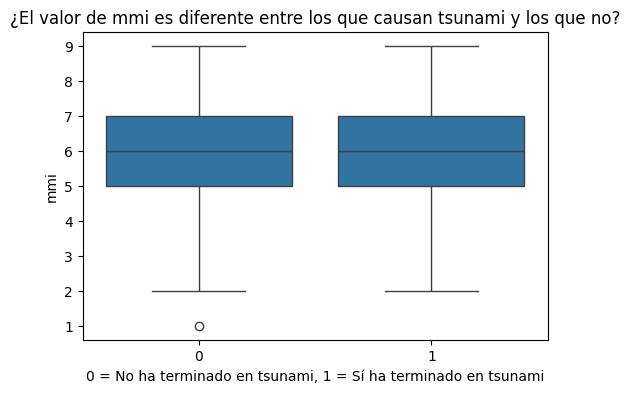

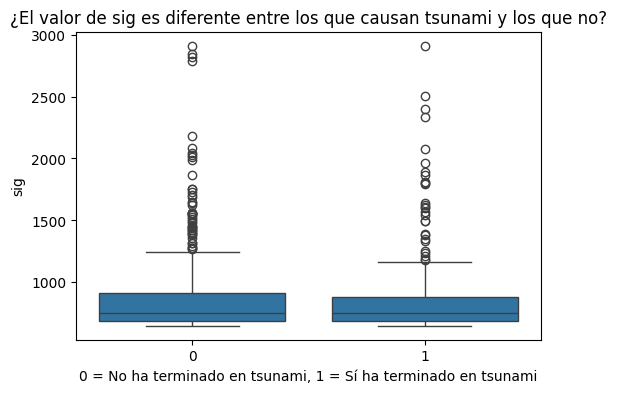

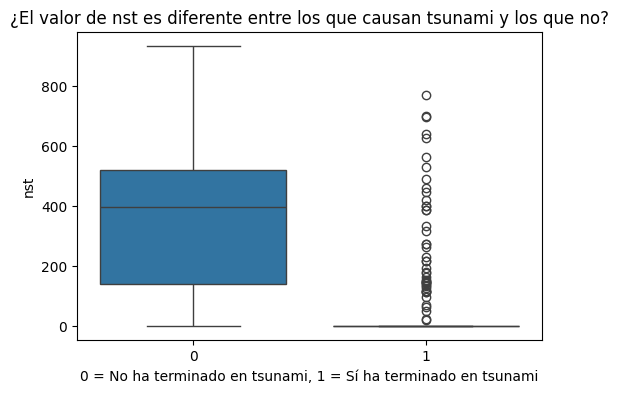

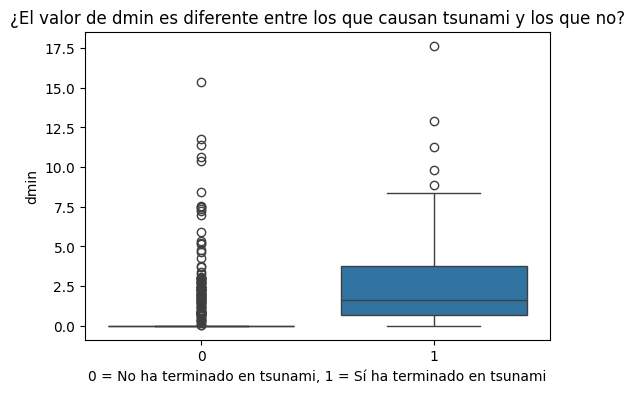

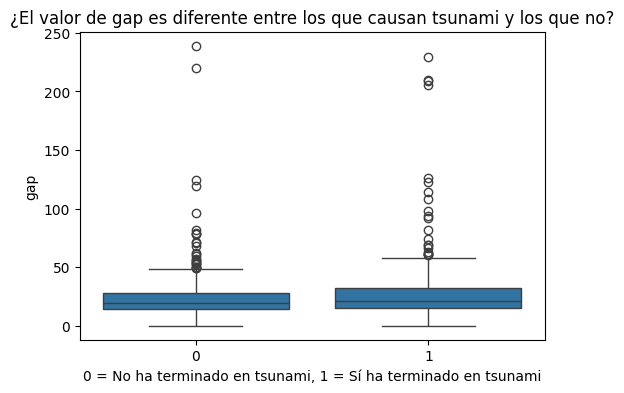

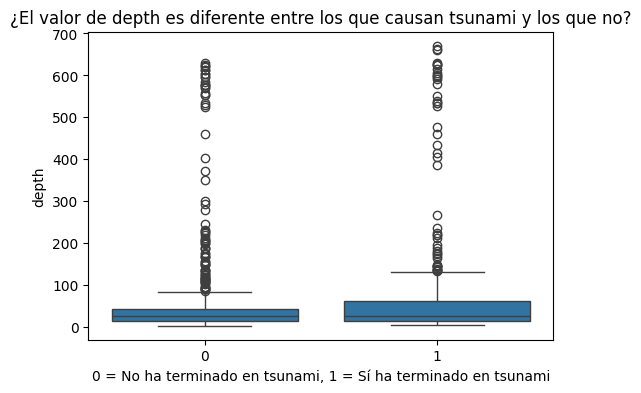

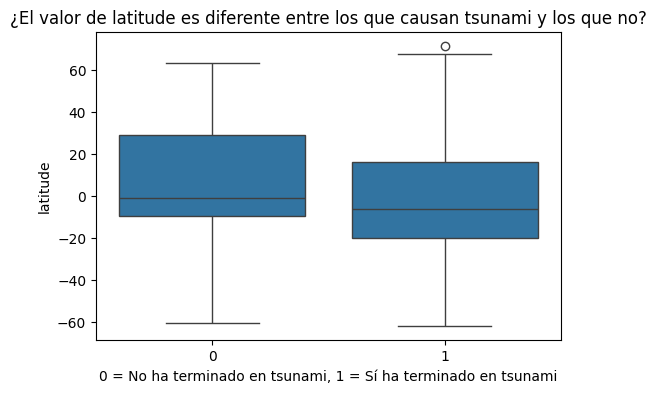

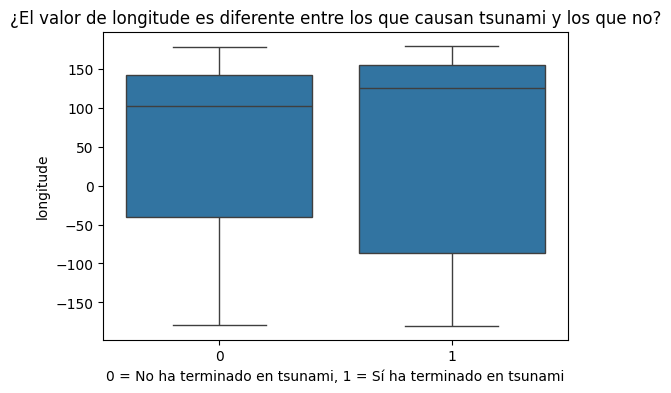

In [13]:
# PASO 3: Ver como las distintas caracteristicas influyen en la ocurrencia de tsunamis
# Crearemos un diagrama de caja para todas las caracteristica numérica usando subplots
for col in ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='tsunami', y=col, data=df)
    plt.title(f'¿El valor de {col} es diferente entre los que causan tsunami y los que no?')
    plt.xlabel('0 = No ha terminado en tsunami, 1 = Sí ha terminado en tsunami')
    plt.ylabel(col)
    plt.show()

In [14]:
# PASO 5: Separar los datos en entrenamiento y prueba
# Así podemos entrenar el modelo con una parte y comprobar si acierta con la otra
from sklearn.model_selection import train_test_split  # Herramienta para separar los datos

# X son las variables que usaremos para predecir, y es la respuesta (enfermedad sí/no)
X = df.drop(columns=['tsunami'])  # Todo menos la columna de respuesta
y = df['tsunami']  # La columna que queremos predecir

# 70% para entrenar, 30% para probar. random_state=8 hace que siempre salga igual.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Ahora tenemos X_train, y_train para entrenar y X_test, y_test para comprobar

### Modelo de Regresión Logarítmica

Accuracy: 0.8085106382978723
AUC: 0.84887195577469
              precision    recall  f1-score   support

           0       0.87      0.80      0.83       138
           1       0.74      0.82      0.78        97

    accuracy                           0.81       235
   macro avg       0.80      0.81      0.81       235
weighted avg       0.81      0.81      0.81       235



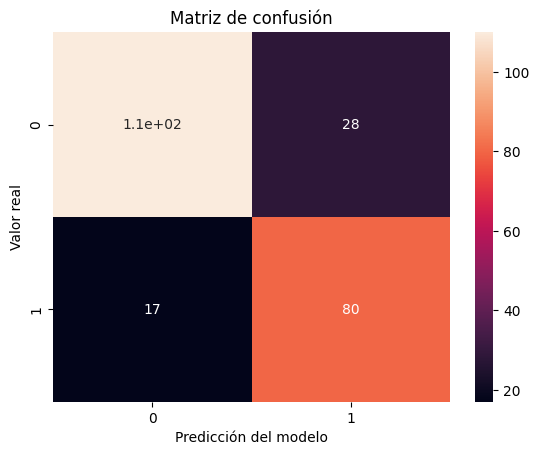

In [15]:
# PASO 6: Crear y probar el modelo de regresión logística
# Este modelo intenta encontrar una fórmula para predecir sí/no
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')  # Para no ver mensajes de advertencia
# Creamos el modelo y lo entrenamos con los datos de entrenamiento
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Hacemos predicciones con los datos de prueba
y_pred = logreg.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred)
auc_logreg = roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1])
# Mostramos qué porcentaje acierta el modelo (accuracy)
print('Accuracy:', acc_logreg)

# Calculamos el AUC, que mide qué tan bien separa sanos de enfermos
print('AUC:', auc_logreg)

# Mostramos un reporte más detallado (precisión, recall, etc.)
print(classification_report(y_test, y_pred))

# Mostramos la matriz de confusión: cuántos aciertos y errores
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.title('Matriz de confusión')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()

### Modelo de Random Forest

Random Forest Accuracy: 0.902127659574468
Random Forest AUC: 0.9602569849096071
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       138
           1       0.85      0.93      0.89        97

    accuracy                           0.90       235
   macro avg       0.90      0.91      0.90       235
weighted avg       0.91      0.90      0.90       235



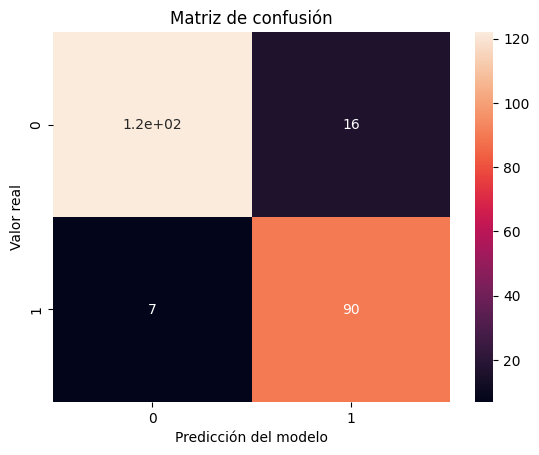

In [16]:
# PASO 7: Probar un modelo más avanzado: Random Forest
# Random Forest es un modelo que combina muchos árboles de decisión para mejorar la predicción
from sklearn.ensemble import RandomForestClassifier

# Creamos el modelo y lo entrenamos
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Hacemos predicciones con Random Forest
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
# Mostramos el porcentaje de aciertos y el AUC
print('Random Forest Accuracy:', acc_rf)
print('Random Forest AUC:', auc_rf)
print(classification_report(y_test, y_pred_rf))
# Mostramos la matriz de confusión: cuántos aciertos y errores
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True)
plt.title('Matriz de confusión')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()

## Clasificación con Boosting

### Importamos librerias

In [17]:
# Modelos de boosting y métricas
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import  r2_score, classification_report, confusion_matrix

import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')  # Para no ver mensajes de advertencia
# Configuración de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

### AdaBoost Classifier

AdaBoost - Accuracy: 0.93
AdaBoost - AUC: 0.95
              precision    recall  f1-score   support

           0       0.98      0.89      0.94       138
           1       0.86      0.98      0.92        97

    accuracy                           0.93       235
   macro avg       0.92      0.94      0.93       235
weighted avg       0.93      0.93      0.93       235



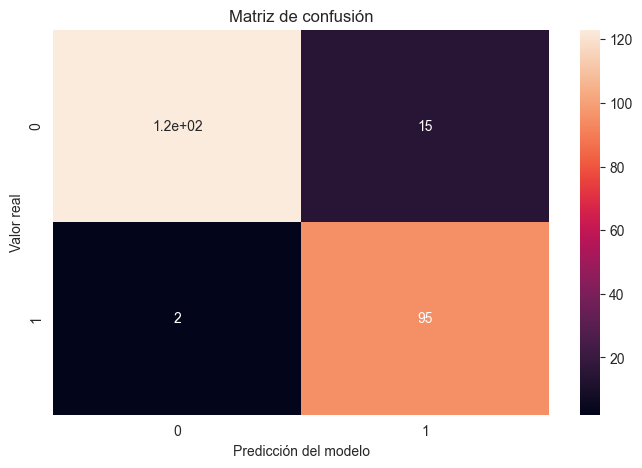

In [25]:
ada_dia = AdaBoostClassifier(n_estimators=50, random_state=42)
ada_dia.fit(X_train, y_train)
y_dia_pred_ada = ada_dia.predict(X_test)
acc_dia_ada = accuracy_score(y_test, y_dia_pred_ada)
auc_dia_ada = roc_auc_score(y_test, ada_dia.predict_proba(X_test)[:,1])
print(f'AdaBoost - Accuracy: {acc_dia_ada:.2f}')
print(f'AdaBoost - AUC: {auc_dia_ada:.2f}')
print(classification_report(y_test, y_dia_pred_ada))

# Mostramos la matriz de confusión: cuántos aciertos y errores
sns.heatmap(confusion_matrix(y_test, y_dia_pred_ada), annot=True)
plt.title('Matriz de confusión')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()

### Gradient Booting Classifier

Gradient Boosting - Accuracy: 0.93
Gradient Boosting - AUC: 0.96
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       138
           1       0.88      0.97      0.92        97

    accuracy                           0.93       235
   macro avg       0.93      0.94      0.93       235
weighted avg       0.94      0.93      0.93       235



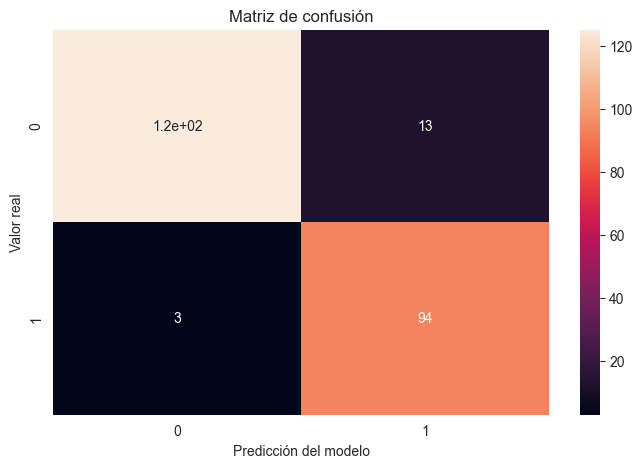

In [23]:
gbr_dia = GradientBoostingClassifier(n_estimators=50, random_state=42)
gbr_dia.fit(X_train, y_train)
y_dia_pred = gbr_dia.predict(X_test)
acc_dia = accuracy_score(y_test, y_dia_pred)
auc_dia = roc_auc_score(y_test, gbr_dia.predict_proba(X_test)[:,1])
print(f'Gradient Boosting - Accuracy: {acc_dia:.2f}')
print(f'Gradient Boosting - AUC: {auc_dia:.2f}')
print(classification_report(y_test, y_dia_pred))

# Mostramos la matriz de confusión: cuántos aciertos y errores
sns.heatmap(confusion_matrix(y_test, y_dia_pred), annot=True)
plt.title('Matriz de confusión')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()

### XGBoost Classifier

XGBoost - Accuracy: 0.92
XGBoost - AUC: 0.97
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       138
           1       0.89      0.93      0.91        97

    accuracy                           0.92       235
   macro avg       0.92      0.92      0.92       235
weighted avg       0.92      0.92      0.92       235



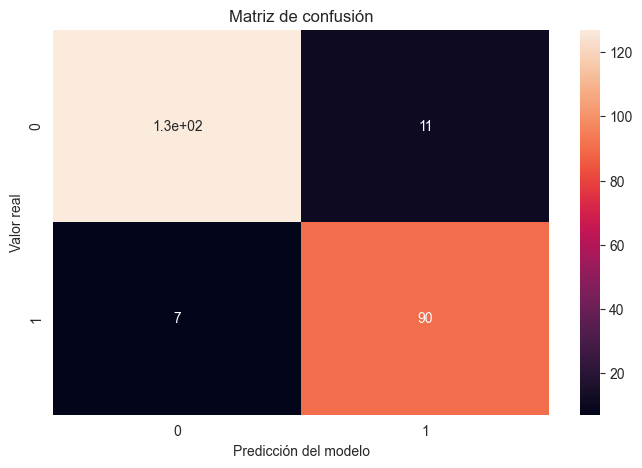

In [24]:
xgb_dia = xgb.XGBClassifier(n_estimators=50, random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0)
xgb_dia.fit(X_train, y_train)
y_dia_pred_xgb = xgb_dia.predict(X_test)
acc_dia_xgb = accuracy_score(y_test, y_dia_pred_xgb)
auc_dia_xgb = roc_auc_score(y_test, xgb_dia.predict_proba(X_test)[:,1])
print(f'XGBoost - Accuracy: {acc_dia_xgb:.2f}')
print(f'XGBoost - AUC: {auc_dia_xgb:.2f}')
print(classification_report(y_test, y_dia_pred_xgb))

# Mostramos la matriz de confusión: cuántos aciertos y errores
sns.heatmap(confusion_matrix(y_test, y_dia_pred_xgb), annot=True)
plt.title('Matriz de confusión')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()

### LightGBM Classifier

[LightGBM] [Info] Number of positive: 207, number of negative: 340
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1004
[LightGBM] [Info] Number of data points in the train set: 547, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.378428 -> initscore=-0.496227
[LightGBM] [Info] Start training from score -0.496227
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

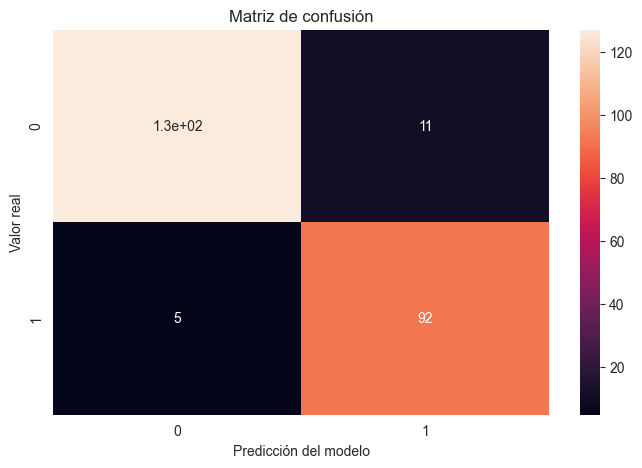

In [26]:
lgbm_dia = lgb.LGBMClassifier(n_estimators=50, random_state=42)
lgbm_dia.fit(X_train, y_train)
y_dia_pred_lgbm = lgbm_dia.predict(X_test)
acc_dia_lgbm = accuracy_score(y_test, y_dia_pred_lgbm)
auc_dia_lgbm = roc_auc_score(y_test, lgbm_dia.predict_proba(X_test)[:,1])
print(f'LightGBM - Accuracy: {acc_dia_lgbm:.2f}')
print(f'LightGBM - AUC: {auc_dia_lgbm:.2f}')
print(classification_report(y_test, y_dia_pred_lgbm))

# Mostramos la matriz de confusión: cuántos aciertos y errores
sns.heatmap(confusion_matrix(y_test, y_dia_pred_lgbm), annot=True)
plt.title('Matriz de confusión')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()

### Comparativa predicción Tsunamis

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.808511,0.740741,0.824742,0.780488,0.848872
1,Random Forest,0.902128,0.849057,0.927835,0.886700,0.960257
2,AdaBoost,0.927660,0.863636,0.979381,0.917874,0.950097
3,GradientBoosting,0.931915,0.878505,0.969072,0.921569,0.955775
4,XGBoost,0.923404,0.891089,0.927835,0.909091,0.968923
5,LightGBM,0.931915,0.893204,0.948454,0.920000,0.972135


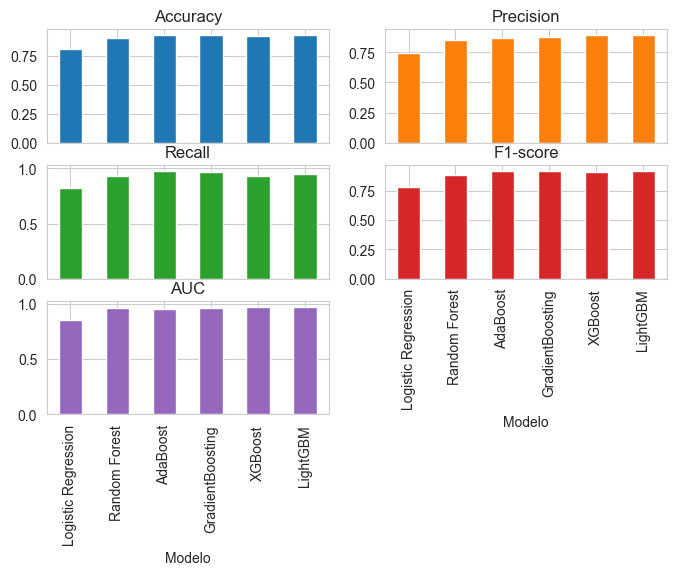

In [27]:
# --- Comparativa Heart Failurre (Clasificación) ---
from sklearn.metrics import precision_score, recall_score, f1_score

# Calcular métricas adicionales para cada modelo
precision_logreg = precision_score(y_test, logreg.predict(X_test))
recall_logreg = recall_score(y_test, logreg.predict(X_test))
f1_logreg = f1_score(y_test, logreg.predict(X_test))

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf) 
f1_rf = f1_score(y_test, y_pred_rf)

precision_dia_ada = precision_score(y_test, y_dia_pred_ada)
recall_dia_ada = recall_score(y_test, y_dia_pred_ada)
f1_dia_ada = f1_score(y_test, y_dia_pred_ada)

precision_dia = precision_score(y_test, y_dia_pred)
recall_dia = recall_score(y_test, y_dia_pred)
f1_dia = f1_score(y_test, y_dia_pred)

precision_dia_xgb = precision_score(y_test, y_dia_pred_xgb)
recall_dia_xgb = recall_score(y_test, y_dia_pred_xgb)
f1_dia_xgb = f1_score(y_test, y_dia_pred_xgb)

precision_dia_lgbm = precision_score(y_test, y_dia_pred_lgbm)
recall_dia_lgbm = recall_score(y_test, y_dia_pred_lgbm)
f1_dia_lgbm = f1_score(y_test, y_dia_pred_lgbm)

resultados_dia = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest', 'AdaBoost', 'GradientBoosting', 'XGBoost', 'LightGBM'],
    'Accuracy': [acc_logreg, acc_rf, acc_dia_ada, acc_dia, acc_dia_xgb, acc_dia_lgbm],
    'Precision': [precision_logreg, precision_rf, precision_dia_ada, precision_dia, precision_dia_xgb, precision_dia_lgbm],
    'Recall': [recall_logreg, recall_rf, recall_dia_ada, recall_dia, recall_dia_xgb, recall_dia_lgbm],
    'F1-score': [f1_logreg, f1_rf, f1_dia_ada, f1_dia, f1_dia_xgb, f1_dia_lgbm],
    'AUC': [auc_logreg, auc_rf, auc_dia_ada, auc_dia, auc_dia_xgb, auc_dia_lgbm]
})
display(resultados_dia)
resultados_dia.plot(x='Modelo', y=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'], kind='bar', subplots=True, layout=(3,2), legend=False, title=['Accuracy','Precision','Recall','F1-score', 'AUC'])
plt.tight_layout()
plt.show()